In [18]:
from rocketpy import Environment, Flight, Rocket, SolidMotor
import numpy
import datetime
import pandas as pd
import numpy as np

In [19]:
%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

In [20]:
env = Environment(latitude=-21.9430528, longitude=-48.9540861, elevation=478)

In [21]:
# Definir data/hora de lançamento (necessário para modelos dependentes do tempo)
import datetime
# Limpar qualquer configuração pré-existente de modelo atmosférico que possa causar re-execução automática
for attr in ("atmospheric_model_type", "atmospheric_model_file", "atmospheric_model_dict"):
    if hasattr(env, attr):
        try:
            setattr(env, attr, None)
        except Exception:
            pass
# usar data atual
env.set_date(datetime.datetime.now())
print('Launch date set to', env.datetime_date)


Launch date set to 2026-07-22 21:53:37.363516+00:00


In [22]:
# GFS  Global Forecast System
env.set_atmospheric_model(type="Forecast", file="GFS")
# env.set_atmospheric_model(type="standard_atmosphere")


Gravity Details

Acceleration of gravity at surface level:    9.7861 m/s²
Acceleration of gravity at  78.996 km (ASL): 9.5482 m/s²


Launch Site Details

Launch Date: 2026-07-22 21:53:37 UTC
Launch Site Latitude: -21.94305°
Launch Site Longitude: -48.95409°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 91457.82 W    7568202.63 S
Launch Site UTM zone: 23K
Launch Site Surface Elevation: 475.6 m


Atmospheric Model Details

Atmospheric Model Type: Forecast
Forecast Maximum Height: 78.996 km
Forecast Time Period: from 2026-07-16 00:00:00 to 2026-08-07 18:00:00 utc
Forecast Hour Interval: 3 hrs
Forecast Latitude Range: From 90.0° to -90.0°
Forecast Longitude Range: From 0.0° to 359.75°

Surface Atmospheric Conditions

Surface Wind Speed: 2.85 m/s
Surface Wind Direction: 318.73°
Surface Wind Heading: 138.73°
Surface Pressure: 957.28 hPa
Surface Temperature: 301.56 K
Surface Air Density: 1.106 kg/m³
Surface Speed of Sound: 348.12 m/s


Earth Model Details

Earth Radius at Launch s

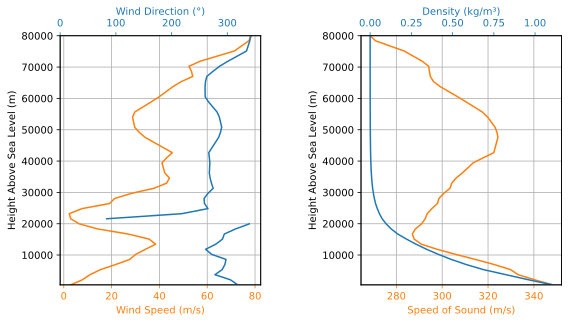

In [23]:
env.info()

In [24]:
# motor

motor_data = pd.read_csv("motor.csv")

In [25]:
print("DataFrame columns:", motor_data.columns)
if 'Unnamed: 0' in motor_data.columns:
    motor_data = motor_data.drop(columns=['Unnamed: 0'])
    print("Dropped 'Unnamed: 0' column.")
    print("Updated DataFrame columns:", motor_data.columns)

# Check for duplicate time values in the first column and remove them
if motor_data.iloc[:, 0].duplicated().any():
    print("Duplicate time values found in the thrust curve data. Removing duplicates.")
    motor_data = motor_data.drop_duplicates(subset=[motor_data.columns[0]])


# Select only the 'Time(s)' and 'Thrust(N)' columns and get the values as a NumPy array
thrust_source_array = motor_data[['Time(s)', 'Thrust(N)']].values


# Now, use the NumPy array as the thrust source to initialize SolidMotor
Dedalo_motor = SolidMotor(
    thrust_source=thrust_source_array, # Use the NumPy array
    dry_mass= 1.86,
    dry_inertia=(0.04718349, 0.04718349, 0.00178498),
    nozzle_radius=0.020715,
    grain_number=3,
    grain_density=1750,
    grain_outer_radius=0.0315,
    grain_initial_inner_radius=0.010,
    grain_initial_height=0.116,
    grain_separation=0,
    grains_center_of_mass_position=0.174, 
    center_of_dry_mass_position=0.24, # verificar
    nozzle_position=-0.05, 
    burn_time=motor_data['Time(s)'].iloc[-1],
    throat_radius=0.008,
    coordinate_system_orientation="nozzle_to_combustion_chamber",
)

print("\nSolidMotor initialized successfully!")

DataFrame columns: Index(['Time(s)', 'Thrust(N)'], dtype='str')

SolidMotor initialized successfully!


Nozzle Details
Nozzle Radius: 0.020715 m
Nozzle Throat Radius: 0.008 m

Grain Details
Number of Grains: 3
Grain Spacing: 0 m
Grain Density: 1750 kg/m3
Grain Outer Radius: 0.0315 m
Grain Inner Radius: 0.01 m
Grain Height: 0.116 m
Grain Volume: 0.000 m3
Grain Mass: 0.569 kg

Motor Details
Total Burning Time: 2.82 s
Total Propellant Mass: 1.707 kg
Structural Mass Ratio: 0.521
Average Propellant Exhaust Velocity: 1112.480 m/s
Average Thrust: 673.437 N
Maximum Thrust: 926.4431 N at 2.79 s after ignition.
Total Impulse: 1899.091 Ns



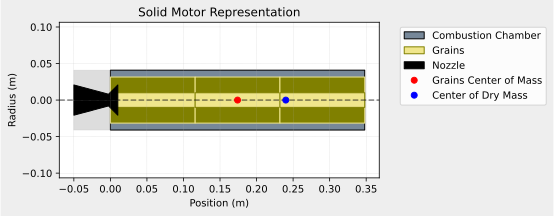

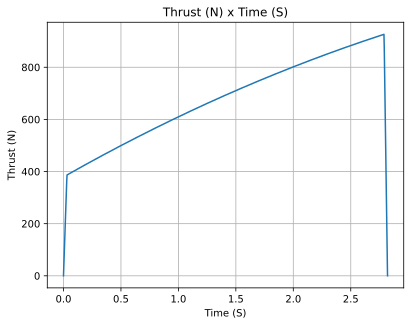

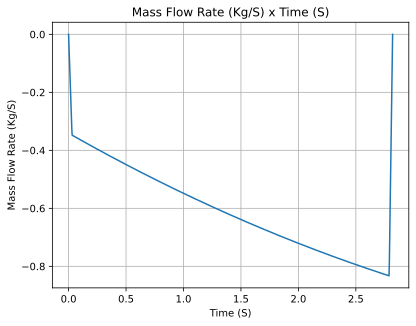

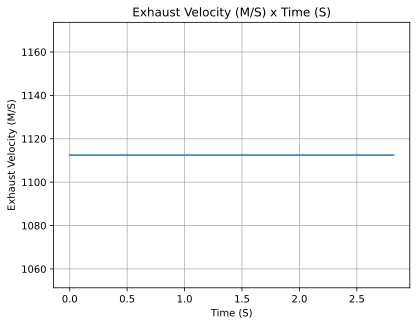

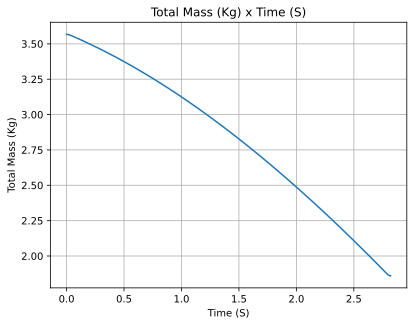

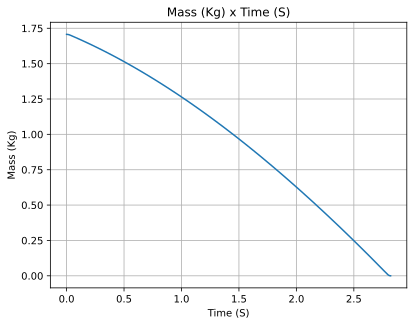

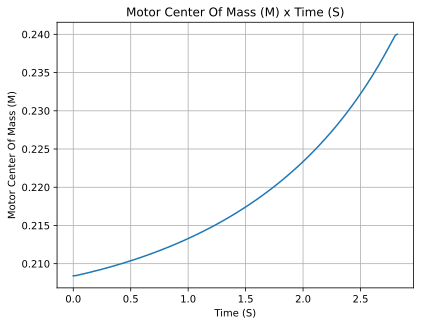

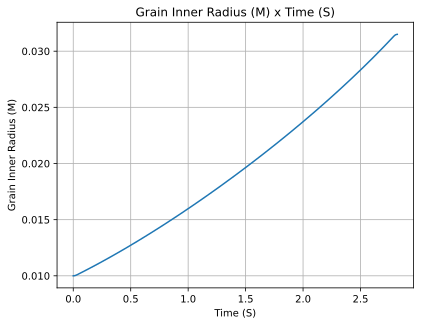

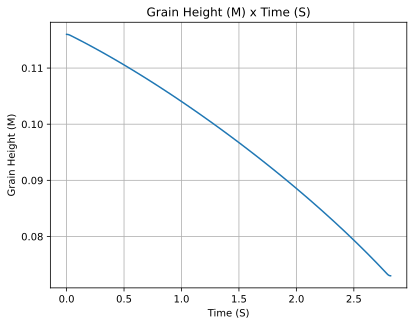

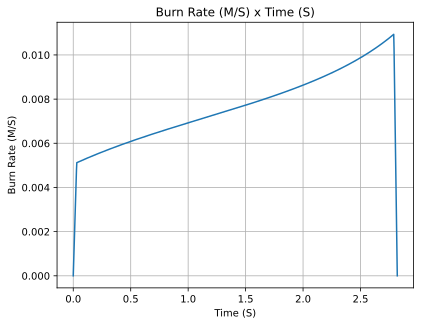

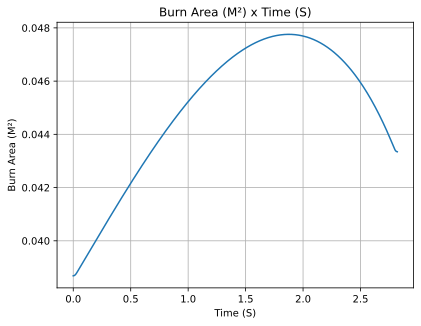

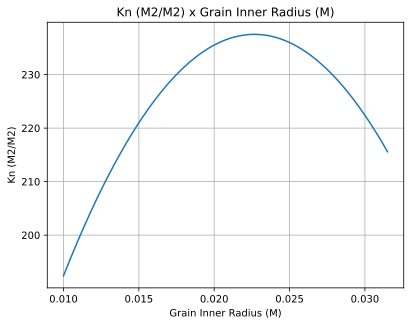

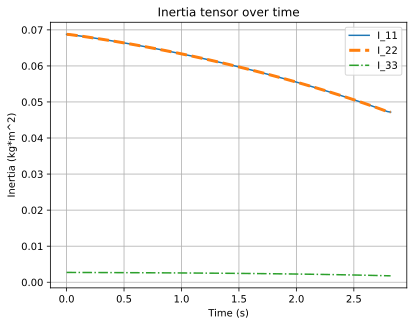

In [26]:
Dedalo_motor.all_info()

/home/vinicius/.local/lib/python3.14/site-packages/rocketpy/mathutils/_calc/polation_1d.py:119: RuntimeWarning: divide by zero encountered in divide
  self._slopes = np.diff(self._y) / np.diff(self._x)
/home/vinicius/.local/lib/python3.14/site-packages/rocketpy/mathutils/_calc/polation_1d.py:119: RuntimeWarning: invalid value encountered in divide
  self._slopes = np.diff(self._y) / np.diff(self._x)


Rocket object created successfully!


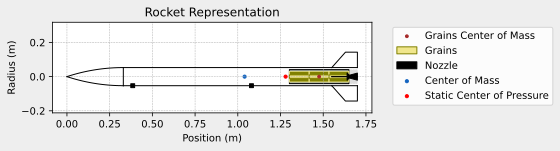

In [27]:
Dedalo_rocket = Rocket(
    radius = (0.106/2),
    mass=5.350,
    power_off_drag="power_off_drag.csv",
    power_on_drag="power_on_drag.csv",
    inertia=(3716597619*(10**-9),3716597619*(10**-9),17183524*(10**-9)),
    center_of_mass_without_motor=0.772,
    coordinate_system_orientation="nose_to_tail",
)

print("Rocket object created successfully!")
Dedalo_rocket.add_motor(Dedalo_motor, position=1.65)

nose_cone = Dedalo_rocket.add_nose(
    length=0.33, kind="Ogive", position=0
)


aletas = Dedalo_rocket.add_trapezoidal_fins(
    n=4,
    root_chord=0.15,
    tip_chord=0.07,
    span=0.09,
    position=1.55,
    cant_angle=0,
)

rail_buttons = Dedalo_rocket.set_rail_buttons(
    upper_button_position=0.385,
    lower_button_position=1.08,
    angular_position=45,
)


main = Dedalo_rocket.add_parachute(
    name="main",
    cd_s=1.5,
    trigger="apogee",      # ejection altitude in meters
    sampling_rate=105,
    lag=1.5,
    radius=0.6,
    noise=(0, 8.3, 0.5),
)
Dedalo_rocket.draw()

In [28]:
Dedalo_rocket.info()


Inertia Details

Rocket Mass: 5.350 kg (without motor)
Rocket Dry Mass: 7.210 kg (with unloaded motor)
Rocket Loaded Mass: 8.917 kg
Rocket Structural Mass Ratio: 0.809
Rocket Inertia (with unloaded motor) 11: 4.326 kg*m2
Rocket Inertia (with unloaded motor) 22: 4.326 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.019 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.053 m
Rocket Frontal Area: 0.008825 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.165 m
Rocket Center of Dry Mass - Nozzle Exit: 0.763 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.539 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.103 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Fins Lift Coefficient Derivative: 6.750/rad

Center of Pressure

Nose Co

In [29]:
Dedalo_flight = Flight(
    rocket=Dedalo_rocket, environment=env, rail_length=4, inclination=85, heading=0, verbose=True
    )

Current Simulation Time: 168.6328 s
>>> Simulation Completed at Time: 167.6466 s


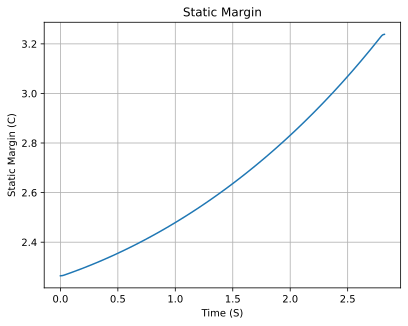

In [30]:
Dedalo_rocket.plots.static_margin()

In [31]:
Dedalo_flight.info()


Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 475.58 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: -0.923 | e1: 0.040 | e2: 0.017 | e3: 0.382
Euler Angles - Spin φ : 315.00° | Nutation θ: -5.00° | Precession ψ: 0.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s


Initial Stability Margin: 2.264 c


Surface Wind Conditions

Frontal Surface Wind Speed: -2.14 m/s
Lateral Surface Wind Speed: -1.87 m/s


Launch Rail

Launch Rail Length: 4 m
Launch Rail Inclination: 85.00°
Launch Rail Heading: 0.00°


Rail Departure State

Rail Departure Time: 0.402 s
Rail Departure Velocity: 14.955 m/s
Rail Departure Stability Margin: 2.335 c
Rail Departure Angle of Attack: 10.690°
Rail Departure Thrust-Weight Ratio: 5.546
Rail Departure Reynolds Number: 9.744e+04


Burn out State

Burn out time: 2.820 s
Altitude at burn out: 705.948 m (ASL) | 230.373 m (AGL)
Rocket speed at burn out: 198.416 m/s
Freestream velocity at burn out: 199.245 m/s
Mach Number at burn out: 0.573
Kinetic energy at burn out: 1.419e+05 J


Apogee State

Apogee Time: 17.362 s
Apogee Altitude: 1901.970 m (ASL) | 1426.395 m (AGL)
Apogee Freestream Speed: 27.074 m/s
Apogee X position: -112.515 m
Apogee Y position: 399.227 m
Apogee latitude: -21.9394648°
Apogee longitude: -48.9551763°


Parachute E

In [35]:
Dedalo_flight.plots

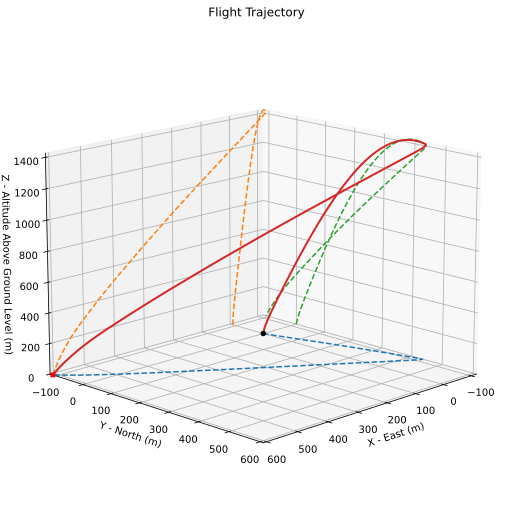

In [33]:
Dedalo_flight.plots.trajectory_3d()